# Вариант 15

\begin{equation}
u_t = \frac{21}{10} \left( u_{xx} + u_{yy} \right) + \lambda e^{-\frac{17t}{10}} \cos(y) + \frac{7797 e^{-\frac{17t}{10}} \sin\left( \frac{12x}{5} \right)}{625}
\end{equation}

\begin{equation}
(x, y, t) \in (0, \pi) \times (-\pi, \pi) \times (0, 1]
\end{equation}

\begin{equation}
u\big|_{t=0} = \frac{6 \sin\left( \frac{12x}{5} \right)}{5} + \frac{19 \cos(y)}{10} + \frac{7}{10}
\end{equation}

\begin{equation}
u_x\big|_{x=0} = \frac{72 e^{-\frac{17t}{10}}}{25}
\end{equation}

\begin{equation}
u\big|_{x=\pi} = \frac{7}{10} + \frac{19 e^{-\frac{17t}{10}} \cos(y)}{10} + \frac{6 \sqrt{\frac{\sqrt{5}}{8}+ \frac{5}{8}} e^{-\frac{17t}{10}}}{5}
\end{equation}

\begin{equation}
u_y\big|_{y=-\pi} = 0
\end{equation}

\begin{equation}
u_y\big|_{y=\pi} = 0
\end{equation}

In [1]:
!pip install deepxde

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.3/192.3 kB 3.9 MB/s eta 0:00:00a 0:00:01


In [2]:
import deepxde as dde
import numpy as np
from deepxde.backend import tf

No backend selected.
Finding available backend...


Using backend: tensorflow.compat.v1
Other supported backends: tensorflow, pytorch, jax, paddle.
paddle supports more examples now and is recommended.


Found tensorflow.compat.v1
Setting the default backend to "tensorflow.compat.v1". You can change it in the ~/.deepxde/config.json file or export the DDE_BACKEND environment variable. Valid options are: tensorflow.compat.v1, tensorflow, pytorch, jax, paddle (all lowercase)


Enable just-in-time compilation with XLA.



# Задание функций вычисления невязок

In [3]:
def pde(x, y):
    u_t = dde.grad.jacobian(y, x, i=0, j=2)  # du / dt
    u_xx = dde.grad.hessian(y, x, i=0, j=0)  # d^2u / dx^2
    u_yy = dde.grad.hessian(y, x, i=1, j=1)  # d^2u / dy^2

    source_term = var * tf.exp(-17 * x[:, 2:3] / 10) * tf.cos(x[:, 1:2]) \
                + (7797 / 625) * tf.exp(-17 * x[:, 2:3] / 10) * tf.sin(12 * x[:, 0:1] / 5)

    return u_t - (21 / 10) * (u_xx + u_yy) - source_term

def initial_condition(x):
    """u(x, y, t=0)"""
    return (6 / 5) * np.sin(12 * x[:, 0:1] / 5) + (19 / 10) * np.cos(x[:, 1:2]) + 7 / 10

def boundary_condition_uxx0(x):
    """u_x(x=0, y, t)"""
    return (-1) * (72 / 25) * np.exp(-17 * x[:, 2:3] / 10)

def boundary_condition_uxpi(x):
    """u(x=pi, y, t)"""
    return 7 / 10 + (19 / 10) * np.exp(-17 * x[:, 2:3] / 10) * np.cos(x[:, 1:2]) \
            + (6 / 5) * np.sqrt(np.sqrt(5) / 8 + 5 / 8) * np.exp(-17 * x[:, 2:3] / 10)

# Задание геометрии

In [4]:
geom = dde.geometry.Rectangle([0, -np.pi], [np.pi, np.pi])
time_domain = dde.geometry.TimeDomain(0, 1)
geomtime = dde.geometry.GeometryXTime(geom, time_domain)

# Задание функций проверки точки на границе

In [5]:
def initial_t(x, on_initial):
    return on_initial and np.isclose(x[2], 0)

def boundary_x_0(x, on_boundary):
    return on_boundary and np.isclose(x[0], 0)

def boundary_x_pi(x, on_boundary):
    return on_boundary and np.isclose(x[0], np.pi)

def boundary_y_neg_pi(x, on_boundary):
    return on_boundary and np.isclose(x[1], -np.pi)

def boundary_y_pi(x, on_boundary):
    return on_boundary and np.isclose(x[1], np.pi)

# Создание начальных и граничных условий и условий на значения функции в точках

In [6]:
def func_zero(x):
    return np.zeros((len(x), 1))

ic = dde.icbc.IC(geomtime, initial_condition, initial_t)
bc_neumann_x_0 = dde.icbc.NeumannBC(geomtime, boundary_condition_uxx0, boundary_x_0)
bc_dirichlet_x_pi = dde.icbc.DirichletBC(geomtime, boundary_condition_uxpi, boundary_x_pi)
bc_neumann_neg_pi = dde.icbc.NeumannBC(geomtime, func_zero, boundary_y_neg_pi)
bc_neumann_pi = dde.icbc.NeumannBC(geomtime, func_zero, boundary_y_pi)

# Создание системы уравнений

In [7]:
data = np.load("/kaggle/input/observations/var-15.npz")
anchors = data["xyt"]
values = data["u"]
bc_anchors = dde.icbc.PointSetBC(anchors, values)

data = dde.data.TimePDE(
    geomtime,
    pde,
    [ic, bc_neumann_x_0, bc_dirichlet_x_pi, bc_neumann_neg_pi, bc_neumann_pi, bc_anchors],
    num_domain=1000,
    num_boundary=500,
    num_initial=700,
    train_distribution="uniform",
    anchors=anchors,
    num_test=1000
)

# Приближение $\lambda = 0.65$

Compiling model...
Building feed-forward neural network...
'build' took 0.074931 s

'compile' took 0.988817 s

Training model...

0         [3.88e+00, 2.71e+00, 8.79e-01, 6.37e-01, 6.62e-03, 8.29e-03, 3.66e-01]    [3.88e+00, 2.71e+00, 8.79e-01, 6.37e-01, 6.62e-03, 8.29e-03, 3.66e-01]    []  
0 [6.50e-01]
1000      [1.09e-02, 2.39e-03, 9.88e-03, 9.08e-04, 2.08e-02, 1.93e-02, 2.51e-04]    [1.09e-02, 2.39e-03, 9.88e-03, 9.08e-04, 2.08e-02, 1.93e-02, 2.51e-04]    []  
1000 [9.90e-01]
2000      [3.71e-03, 7.87e-04, 1.20e-02, 2.37e-04, 1.51e-02, 1.44e-02, 4.22e-05]    [3.71e-03, 7.87e-04, 1.20e-02, 2.37e-04, 1.51e-02, 1.44e-02, 4.22e-05]    []  
2000 [8.66e-01]
3000      [2.20e-03, 5.43e-04, 1.28e-02, 1.89e-04, 1.34e-02, 1.32e-02, 9.34e-05]    [2.20e-03, 5.43e-04, 1.28e-02, 1.89e-04, 1.34e-02, 1.32e-02, 9.34e-05]    []  
3000 [7.60e-01]

Best model at step 3000:
  train loss: 4.23e-02
  test loss: 4.23e-02
  test metric: []

'train' took 105.444019 s



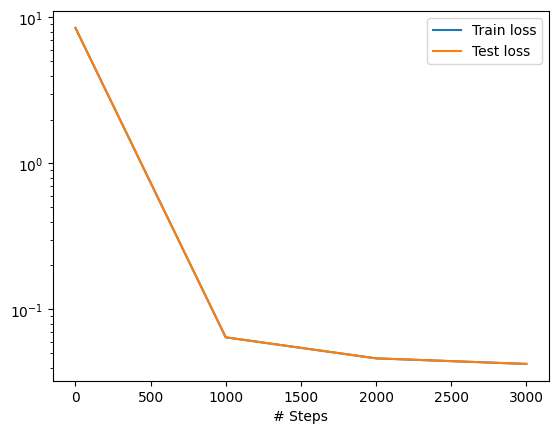

Compiling model...
'compile' took 0.687065 s

Training model...

Step      Train loss                                                                Test loss                                                                 Test metric
3000      [2.20e-03, 5.43e-04, 1.28e-02, 1.89e-04, 1.34e-02, 1.32e-02, 9.34e-05]    [2.20e-03, 5.43e-04, 1.28e-02, 1.89e-04, 1.34e-02, 1.32e-02, 9.34e-05]    []  
3000 [7.60e-01]
4000      [1.93e-03, 4.05e-04, 1.31e-02, 1.40e-04, 1.30e-02, 1.28e-02, 3.81e-05]    [1.93e-03, 4.05e-04, 1.31e-02, 1.40e-04, 1.30e-02, 1.28e-02, 3.81e-05]    []  
4000 [7.49e-01]
5000      [1.62e-03, 3.66e-04, 1.34e-02, 1.28e-04, 1.27e-02, 1.25e-02, 3.52e-05]    [1.62e-03, 3.66e-04, 1.34e-02, 1.28e-04, 1.27e-02, 1.25e-02, 3.52e-05]    []  
5000 [7.38e-01]
6000      [1.38e-03, 3.38e-04, 1.36e-02, 1.27e-04, 1.23e-02, 1.23e-02, 3.21e-05]    [1.38e-03, 3.38e-04, 1.36e-02, 1.27e-04, 1.23e-02, 1.23e-02, 3.21e-05]    []  
6000 [7.28e-01]
7000      [1.21e-03, 3.20e-04, 1.38e-02, 1.29e-04

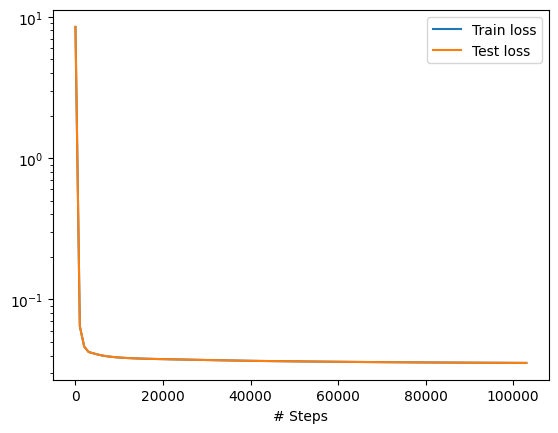

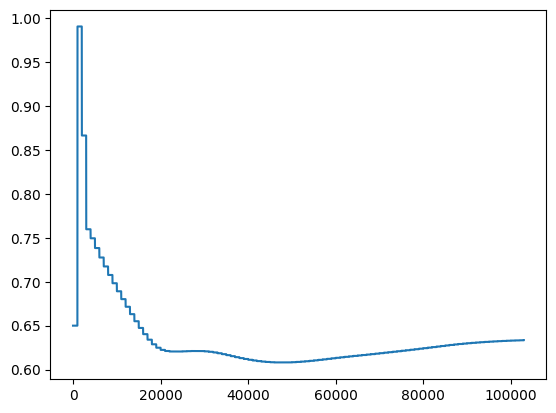

In [11]:
import matplotlib.pyplot as plt
var = dde.Variable(0.65)

class VariableTracker(dde.callbacks.Callback):
    # Callback для сохранения истории значений обучаемой переменной
    def __init__(self, var_list, period):
        super().__init__()

        self.var_list = var_list if isinstance(var_list, list) else [var_list]
        self.period = period
        self.values = []
        self.epochs_since_last = 0
        
    def on_train_begin(self):
        self.values.append([x.value[0] for x in self.var_list])

    def on_epoch_end(self):
        self.epochs_since_last += 1
        if self.epochs_since_last >= self.period:
            self.epochs_since_last = 0
            self.on_train_begin()

    def on_train_end(self):
        if not self.epochs_since_last == 0:
            self.on_train_begin()

layer_size = [3] + [30] * 4 + [1]
activation = "tanh"
initializer = "Glorot uniform"
net = dde.nn.FNN(layer_size, activation, initializer)

variable = dde.callbacks.VariableValue(var, period=1000)
pde_resampler = dde.callbacks.PDEPointResampler(period=200)
tracker = VariableTracker(variable, 1)

model = dde.Model(data, net)
model.compile("adam", lr=1e-3, external_trainable_variables=var)
losshistory, train_state = model.train(iterations=3000, callbacks=[variable, pde_resampler, tracker])
model.compile("adam", lr=1e-5, external_trainable_variables=var)  
losshistory, train_state = model.train(iterations=100000, callbacks=[variable, pde_resampler, tracker])
dde.saveplot(losshistory, train_state, issave=False, isplot=True)
plt.plot(tracker.values)
plt.show()

Compiling model...
Building feed-forward neural network...
'build' took 0.073814 s

'compile' took 1.047477 s

Training model...

0         [3.88e+00, 2.71e+00, 8.79e-01, 6.37e-01, 6.62e-03, 8.29e-03, 3.66e-01]    [3.88e+00, 2.71e+00, 8.79e-01, 6.37e-01, 6.62e-03, 8.29e-03, 3.66e-01]    []  
0 [6.50e-01]
1000      [3.26e+00, 2.47e+00, 6.23e-01, 3.13e-01, 3.33e-03, 2.56e-02, 1.22e-01]    [3.26e+00, 2.47e+00, 6.23e-01, 3.13e-01, 3.33e-03, 2.56e-02, 1.22e-01]    []  
1000 [6.61e-01]
2000      [2.68e+00, 2.37e+00, 5.11e-01, 2.94e-01, 2.54e-03, 1.49e-02, 9.37e-02]    [2.68e+00, 2.37e+00, 5.11e-01, 2.94e-01, 2.54e-03, 1.49e-02, 9.37e-02]    []  
2000 [6.67e-01]
3000      [2.34e+00, 2.09e+00, 5.27e-01, 2.21e-01, 5.18e-03, 1.43e-02, 6.78e-02]    [2.34e+00, 2.09e+00, 5.27e-01, 2.21e-01, 5.18e-03, 1.43e-02, 6.78e-02]    []  
3000 [6.80e-01]
4000      [2.00e+00, 1.74e+00, 5.44e-01, 1.62e-01, 1.23e-02, 2.25e-02, 4.03e-02]    [2.00e+00, 1.74e+00, 5.44e-01, 1.62e-01, 1.23e-02, 2.25e-02, 4.03e-02]   

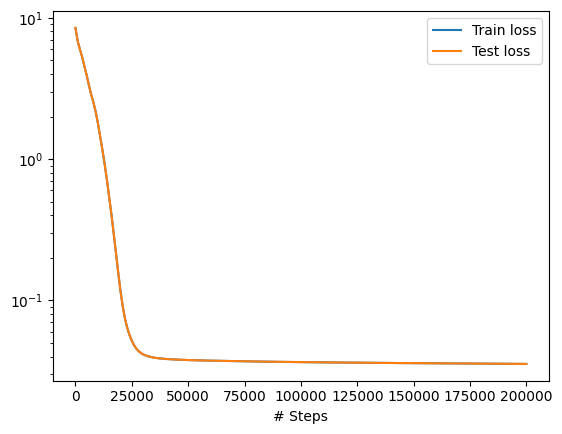

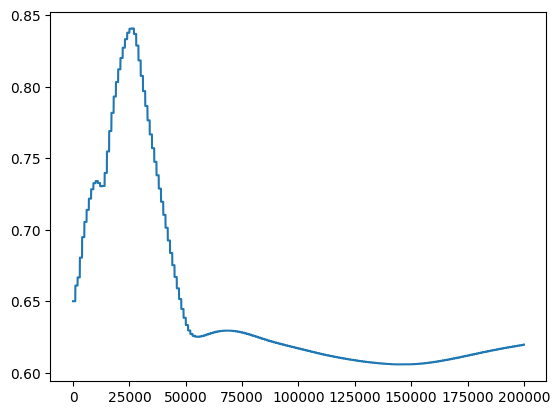

In [13]:
'''
import matplotlib.pyplot as plt
var = dde.Variable(0.65)
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

class VariableTracker(dde.callbacks.Callback):
    # Callback для сохранения истории значений обучаемой переменной
    def __init__(self, var_list, period):
        super().__init__()

        self.var_list = var_list if isinstance(var_list, list) else [var_list]
        self.period = period
        self.values = []
        self.epochs_since_last = 0
        
    def on_train_begin(self):
        self.values.append([x.value[0] for x in self.var_list])

    def on_epoch_end(self):
        self.epochs_since_last += 1
        if self.epochs_since_last >= self.period:
            self.epochs_since_last = 0
            self.on_train_begin()

    def on_train_end(self):
        if not self.epochs_since_last == 0:
            self.on_train_begin()

layer_size = [3] + [30] * 4 + [1]
activation = "tanh"
initializer = "Glorot uniform"
net = dde.nn.FNN(layer_size, activation, initializer)

variable = dde.callbacks.VariableValue(var, period=1000)
pde_resampler = dde.callbacks.PDEPointResampler(period=200)
tracker = VariableTracker(variable, 1)

model = dde.Model(data, net)
model.compile("adam", lr=1e-5, external_trainable_variables=var)  
losshistory, train_state = model.train(iterations=200000, callbacks=[variable, pde_resampler, tracker])
dde.saveplot(losshistory, train_state, issave=False, isplot=True)
plt.plot(tracker.values)
plt.show()
'''